# Imports

In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from scipy import signal
from scipy.signal import welch 
from scipy.optimize import curve_fit
import colorednoise as cn

# Goal and Motivation

Hi ! My name is Paul. I'm a PhD student in astrophysics. In my research, I modelize spectroscopic observations. I have the intuition that the photon-noise in the spectra might not be exactly a white noise due to all the manipulations of the data through the preprocessing steps. Thus, I wanted to measure and modelize this actual noise in order to injecting it into my models. I didn't find on the internet someone providing the code to generate noise from a custom Power Spectrum Density (PSD) model so I've made my own :) (`generate_custom_noise.py`). 

The Notebook is a concrete example of me building a noise model from real SPIRou observations. 

Enjoy ! :)

# Observations 
## Loading SPIRou corrected spectra
We load only a fraction of 15 nm of all the EV_Lac's spectra aquired with SPIRou

This portion do not contains any deep stellar lines or tellurics 

In [4]:
cwd = '/media/paul/One Touch12/UdeM/lbl_spirou/science/EV_LAC_SLINKY05'

In [5]:
os.chdir(cwd)
lambd_all = []
flux_all  = []
snrs = []
order = 44
for (root, dirs, file) in os.walk(cwd):
    for f in tqdm(sorted(file)):
        if 't.fits' in f:
            nthfile = fits.open(f, memmap=False)
            lambd_all.append(nthfile[2].data[order][540:-540])
            flux_all.append(nthfile[1].data[order][540:-540])
            #snrs.append(nthfile[0].header['SPEMSNR'])
            nthfile.close()

lambd_all = np.array(lambd_all)
flux_all = np.array(flux_all)
#SNR = np.mean(snrs)
#print(f'Mean SNR: {SNR:.2f}')

100%|██████████| 673/673 [01:22<00:00,  8.14it/s]


In [6]:
lambd_all[0,0]-lambd_all[0,-1]

-50.03842387400937

In [7]:
print(lambd_all[0,0], lambd_all[0,-1])

2170.0952595427 2220.1336834167096


In [8]:
used_times = []
for idx in tqdm(range(len(flux_all)), leave=False):
    flx = flux_all[idx][~np.isnan(flux_all[idx])]
    if len(flx) == len(flux_all[0]):
        used_times.append(True)
    else:
        used_times.append(False)

used_times = np.array(used_times)

lambd_all = lambd_all[used_times]
flux_all = flux_all[used_times]

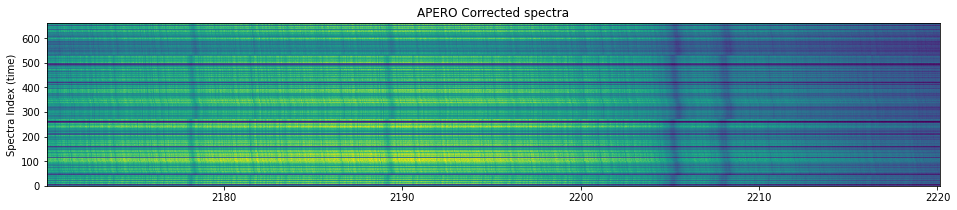

In [9]:
plt.figure(figsize=(16, 3))
plt.imshow(flux_all, interpolation = 'none', extent=[min(lambd_all[0]), max(lambd_all[0]), 0, len(lambd_all)], aspect ='auto')
plt.ylabel('Spectra Index (time)')
plt.title('APERO Corrected spectra')
plt.savefig("/media/paul/One Touch12/Paper1/noise_1.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [10]:
img1 = np.copy(flux_all)

Not all the oservations were realized under the same condition which obviously results in different intensities 
so the first step is to standardize the observations
## Standardisation

In [11]:
#standardize
ma_flux_all  = np.ma.MaskedArray(flux_all, mask=np.isnan(flux_all))
avg_flux_all = np.ma.average(ma_flux_all, axis=1)
std_flux_all = np.ma.average((ma_flux_all-avg_flux_all.reshape(-1,1))**2, axis=1)
avg_flux_all = avg_flux_all.data.reshape(-1,1)
std_flux_all = np.sqrt(std_flux_all.data.reshape(-1,1))
FLX = (np.copy(flux_all) - avg_flux_all)/std_flux_all
#FLX = FLX.T

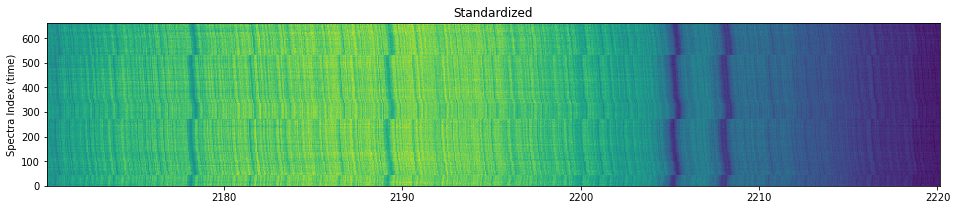

In [12]:
plt.figure(figsize=(16, 3))
plt.imshow(FLX, interpolation = 'none', extent=[min(lambd_all[0]), max(lambd_all[0]), 0, len(lambd_all)], aspect ='auto')
plt.ylabel('Spectra Index (time)')
plt.title('Standardized')
plt.savefig("/media/paul/One Touch12/Paper1/noise_2.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [13]:
img2 = np.copy(FLX)

We then correct roughtly the blazing using a quadratic function

## Deblazing

In [14]:
#fit quadra
for i in range(len(FLX)):
    quadra = np.poly1d(np.polyfit(lambd_all[i], FLX[i], 2))
    FLX[i] -= quadra(lambd_all[i])

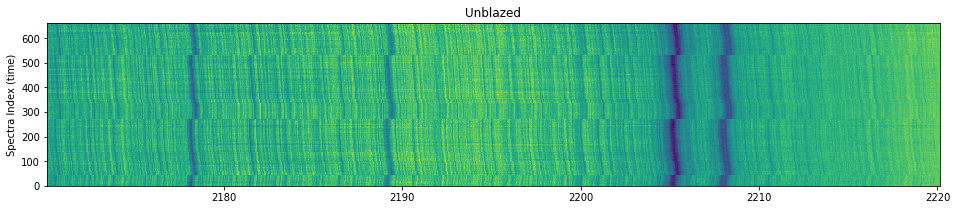

In [15]:
plt.figure(figsize=(16, 3))
plt.imshow(FLX, interpolation = 'none', extent=[min(lambd_all[0]), max(lambd_all[0]), 0, len(lambd_all)], aspect ='auto')
plt.ylabel('Spectra Index (time)')
plt.title('Unblazed')
plt.savefig("/media/paul/One Touch12/Paper1/noise_3.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [16]:
img3 = np.copy(FLX)

We correct the doppler shift due to the BERV using a CCF

## Correcting the BERV

In [17]:
# determine lag 

ref = FLX[0]
lag = np.zeros(len(FLX))

for i in range(len(FLX)):
    correlation = signal.correlate(ref, FLX[i], mode='full')
    lags = signal.correlation_lags(ref.size, FLX[i].size, mode='full')
    lag[i] = lags[np.argmax(correlation)]

In [18]:
lag -= int(np.min(lag))

In [19]:
fluxes_shifted = np.zeros((len(FLX), len(FLX[0])+int(np.max(lag))))
for i in range(len(fluxes_shifted)):
    for j in range(len(FLX[0])):
            fluxes_shifted[i][j+int(lag[i])] = FLX[i][j]
        

In [20]:
fluxes_shifted = fluxes_shifted[:, int(np.max(lag)):-int(np.max(lag))]

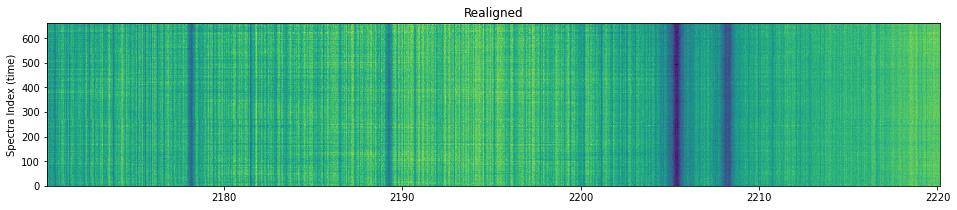

In [21]:
plt.figure(figsize=(16, 3))
plt.imshow(fluxes_shifted, interpolation = 'none', extent=[min(lambd_all[0]), max(lambd_all[0]), 0, len(lambd_all)], aspect ='auto')
plt.ylabel('Spectra Index (time)')
plt.title('Realigned')
plt.savefig("/media/paul/One Touch12/Paper1/noise_4.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [22]:
img4 = np.copy(fluxes_shifted)

We can finally remove all those faint stellar lines by substracting their template

## Removing spectral lines

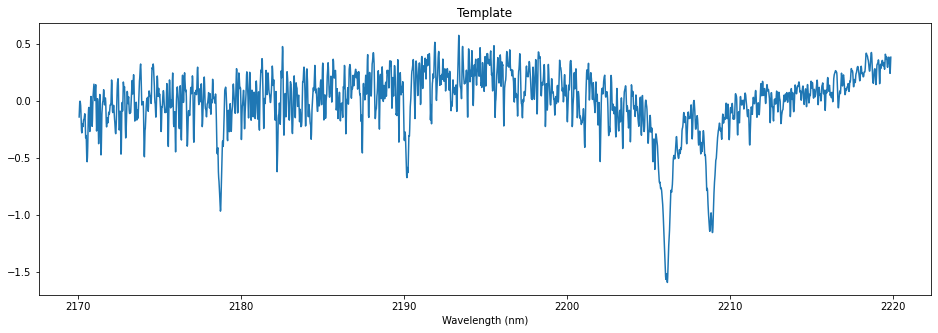

In [23]:
template = np.nanmean(fluxes_shifted, axis=0)
lambd = lambd_all[0][:-int(np.max(lag))]
plt.figure(figsize=(16, 5))
plt.plot(lambd, template)
plt.title('Template')
plt.xlabel('Wavelength (nm)')
plt.show()

In [24]:
fluxes_shifted -= template

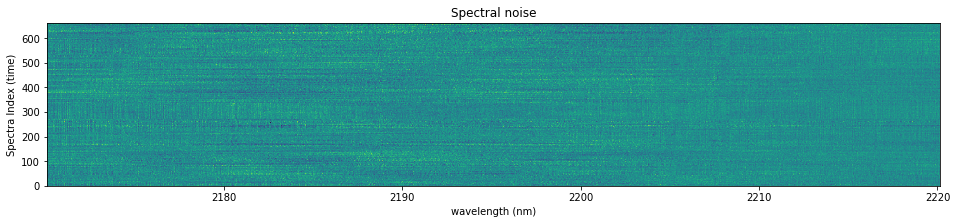

In [25]:
plt.figure(figsize=(16, 3))
plt.imshow(fluxes_shifted, interpolation = 'none', extent=[min(lambd_all[0]), max(lambd_all[0]), 0, len(lambd_all)], aspect ='auto')
plt.ylabel('Spectra Index (time)')
plt.xlabel('wavelength (nm)')
plt.title('Spectral noise')
plt.savefig("/media/paul/One Touch12/Paper1/noise_5.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [26]:
img5 = np.copy(fluxes_shifted)

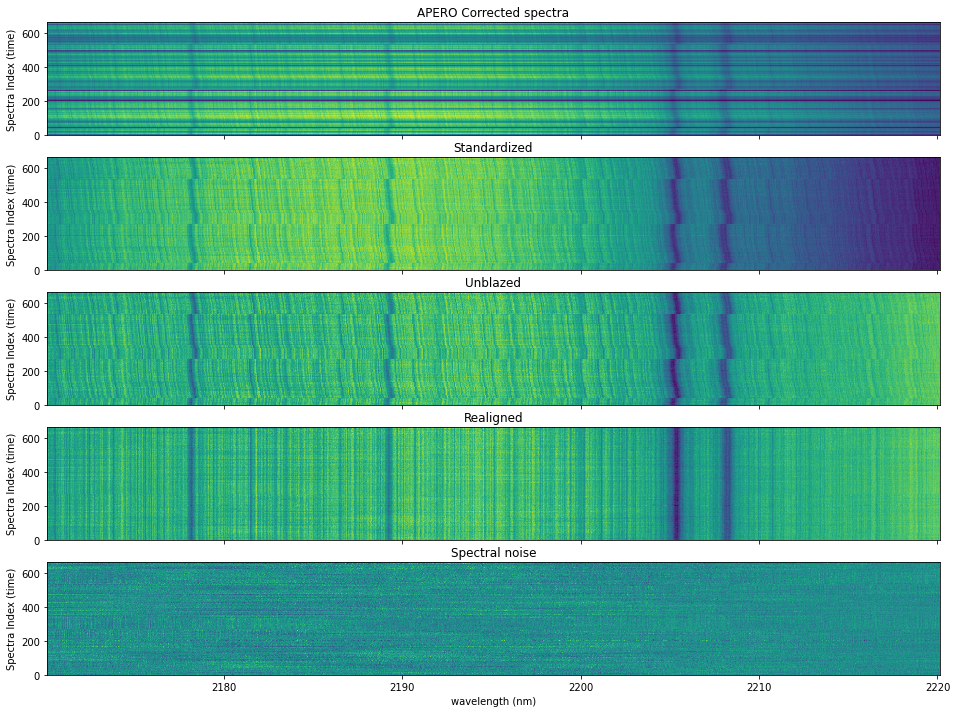

In [27]:
fig, ax = plt.subplots(5, 1, sharex='col', figsize=(16,12))

ax[0].imshow(img1, interpolation = 'none', extent=[min(lambd_all[0]), max(lambd_all[0]), 0, len(lambd_all)], aspect ='auto')
ax[0].set_ylabel('Spectra Index (time)')
ax[0].set_title('APERO Corrected spectra')

ax[1].imshow(img2, interpolation = 'none', extent=[min(lambd_all[0]), max(lambd_all[0]), 0, len(lambd_all)], aspect ='auto')
ax[1].set_ylabel('Spectra Index (time)')
ax[1].set_title('Standardized')

ax[2].imshow(img3, interpolation = 'none', extent=[min(lambd_all[0]), max(lambd_all[0]), 0, len(lambd_all)], aspect ='auto')
ax[2].set_ylabel('Spectra Index (time)')
ax[2].set_title('Unblazed')

ax[3].imshow(img4, interpolation = 'none', extent=[min(lambd_all[0]), max(lambd_all[0]), 0, len(lambd_all)], aspect ='auto')
ax[3].set_ylabel('Spectra Index (time)')
ax[3].set_title('Realigned')

ax[4].imshow(img5, interpolation = 'none', extent=[min(lambd_all[0]), max(lambd_all[0]), 0, len(lambd_all)], aspect ='auto')
ax[4].set_ylabel('Spectra Index (time)')
ax[4].set_xlabel('wavelength (nm)')
ax[4].set_title('Spectral noise')
plt.savefig("/media/paul/One Touch12/Paper1/noise.pdf", format="pdf", bbox_inches="tight")
plt.show()

We succesfully isolates the spectral noise, now lets have a look to its PSD

# Get spectral density 

100%|██████████| 663/663 [00:00<00:00, 1331.73it/s]


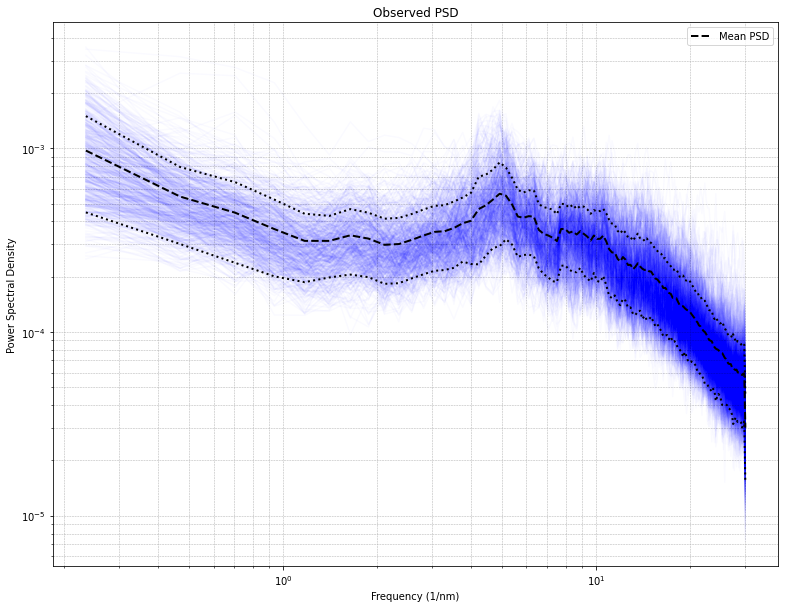

In [28]:
fr = 1/(np.mean(lambd[1:] - lambd[:-1]))
PSD = []
plt.figure(figsize=(13, 10))
for i in tqdm(range(len(fluxes_shifted))):

    frequencies, psd = welch(fluxes_shifted[i], fs=fr)

    valid = frequencies > 0.
    
    f = frequencies[valid] 
    PSD.append(psd[valid]) 
    plt.loglog(f, psd[valid], c='b', alpha = 0.02)
    
PSD = np.array(PSD)
plt.loglog(f, np.mean(PSD, axis = 0), 'k--', linewidth = 2,label='Mean PSD')
plt.loglog(f, np.mean(PSD, axis = 0)+ np.std(PSD, axis = 0), 'k:', linewidth = 2)
plt.loglog(f, np.mean(PSD, axis = 0)- np.std(PSD, axis = 0), 'k:', linewidth = 2)
plt.xlabel('Frequency (1/nm)')
plt.ylabel('Power Spectral Density')
plt.title('Observed PSD')
plt.legend()
plt.grid(which='both', linestyle = '--', linewidth=0.5)
plt.show()

In [29]:
print(1/fr)

0.016649607267765664


The PSD we observe is definitly not flat so the spectral not is definitly not white. 
More complex than the traditional power laws used for colored noises. 
The most meaningful feature to me is the lack of high frequencies, it dramaticaly falls. 

# Modelizing and fitting a PSD 

It seems that we can distinguish two separated regime in the osberved PSD: 

In the low frequencies, before the breaking frequency of $10 nm^{-1}$, the PSD seems to be more or less flat, or slightly decreasing. We can therefore modelize it as a classic power law. 

Then for higher frequencies, the decrease is more dramatic and the slope seems to increase with the frequency. We will try to modelize it as a quadratic power law

In [30]:
def power_law(f, a, b):
    return(a/(f**b))

def quad_power_law(f, a, b, c):
    return a * f ** (-b +c * np.log(f))

def const(f, a):
    return(np.ones_like(f)*a)

100%|██████████| 663/663 [00:00<00:00, 1193.82it/s]


Fitted Quad parameters :
Amplitude a : 1.77e-05
Base Slope b : -3.24
Curvature c : -0.86
Fitted parameters :
Amplitude a : 3.42e-04
Slope b : 0.69
Fitted parameters :
Amplitude a : 3.59e-04


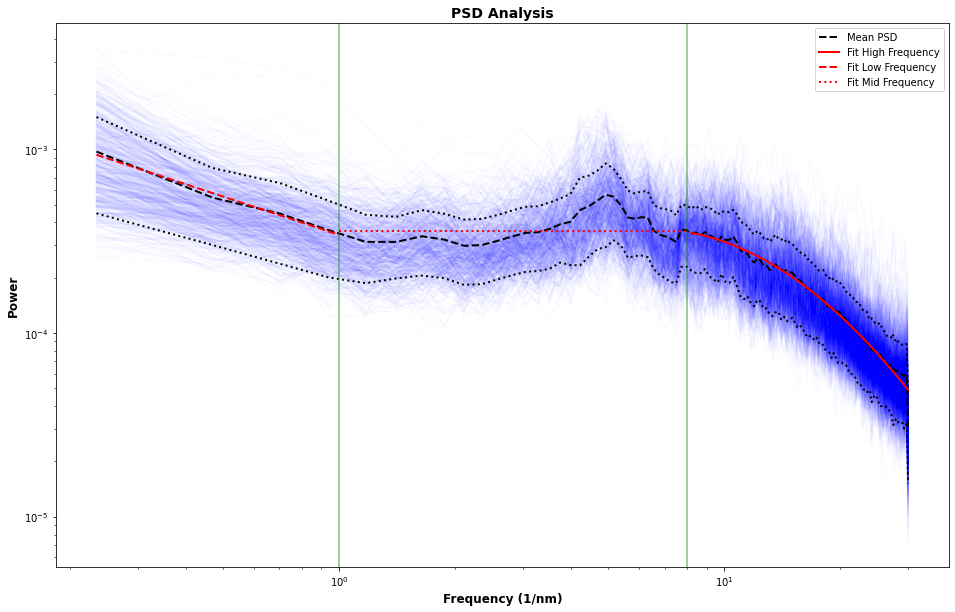

In [37]:
PSD = []
plt.figure(figsize=(16, 10))
for i in tqdm(range(len(fluxes_shifted))):

    frequencies, psd = welch(fluxes_shifted[i], fs=fr)

    valid = frequencies > 0.
    
    f = frequencies[valid] 
    PSD.append(psd[valid]) 
    plt.loglog(f, psd[valid], c='b', alpha = 0.02)
    
PSD = np.array(PSD)
plt.loglog(f, np.mean(PSD, axis = 0), 'k--', linewidth = 2,label='Mean PSD')
plt.loglog(f, np.mean(PSD, axis = 0)+ np.std(PSD, axis = 0), 'k:', linewidth = 2)
plt.loglog(f, np.mean(PSD, axis = 0)- np.std(PSD, axis = 0), 'k:', linewidth = 2)

f_break_high = 8.
f_break_low  = 1.

lo_freq  = f <= f_break_low 
hi_freq  = f >= f_break_high
mid_freq = [f_break_low <= fi <= f_break_high for fi in f]

popt, pcov = curve_fit(quad_power_law, f[hi_freq], np.mean(PSD, axis = 0)[hi_freq], sigma = np.std(PSD, axis = 0)[hi_freq])

a_fit, b_fit, c_fit = popt
print("Fitted Quad parameters :")
print(f"Amplitude a : {a_fit:.2e}")
print(f"Base Slope b : {b_fit:.2f}")
print(f"Curvature c : {c_fit:.2f}")

plt.loglog(f[hi_freq], quad_power_law(f[hi_freq], *popt), 'r', linewidth = 2,label='Fit High Frequency')

popt, pcov = curve_fit(power_law, f[lo_freq], np.mean(PSD, axis = 0)[lo_freq], sigma = np.std(PSD, axis = 0)[lo_freq])

a_fit, b_fit = popt
print("Fitted parameters :")
print(f"Amplitude a : {a_fit:.2e}")
print(f"Slope b : {b_fit:.2f}")

f_gridraw_low = np.linspace(min(f[lo_freq]), f_break_low, 100)

plt.loglog(f_gridraw_low, power_law(f_gridraw_low, *popt), 'r--', linewidth = 2,label='Fit Low Frequency')



popt, pcov = curve_fit(const, f[mid_freq], np.mean(PSD, axis = 0)[mid_freq], sigma = np.std(PSD, axis = 0)[mid_freq])

a_fit = popt[0]
print("Fitted parameters :")
print(f"Amplitude a : {a_fit:.2e}")

f_gridraw_mid = np.linspace(f_break_low, f_break_high, 100)

plt.loglog(f_gridraw_mid, const(f_gridraw_mid, *popt), 'r:', linewidth = 2,label='Fit Mid Frequency')




plt.axvline(f_break_low, c='g', alpha=0.5)
plt.axvline(f_break_high, c='g', alpha=0.5)
plt.xlabel('Frequency (1/nm)', size=12, weight='bold')
plt.ylabel('Power', size=12, weight='bold')
plt.title('PSD Analysis', size=14, weight='bold')
plt.legend()
#plt.grid(which='both', linestyle = '--', linewidth=0.5)
plt.savefig("/media/paul/One Touch12/Paper1/PSD_analysis.pdf", format="pdf", bbox_inches="tight")
plt.show()

Not to bad, lets use this function and generate noise with it


# Generate White Noise from my custom PSD

The `generate_noise_from_psd()` function is basically generating white noise and then use your custom PSD function to filters it and tadaaa. 

In [32]:
def custom_psd_function(freq_grid):
    a_low, b_low = 3.42e-4, 0.69
    a_mid = 3.59e-4
    a_high, b_high, c_high = 1.77e-5, -3.24, -0.86
    f_break_high = 8.
    f_break_low  = 1.
    psd = np.zeros_like(freq_grid)
    for f in range(len(freq_grid)):
        # low frequency
        if freq_grid[f] <= f_break_low :
            psd[f] = a_low/(freq_grid[f]**b_low)
        # high frequency
        elif freq_grid[f] >= f_break_high :
            psd[f] = a_high * freq_grid[f] ** (-b_high + c_high * np.log(freq_grid[f]))
        else :
            psd[f] = a_mid
    return(psd)
    

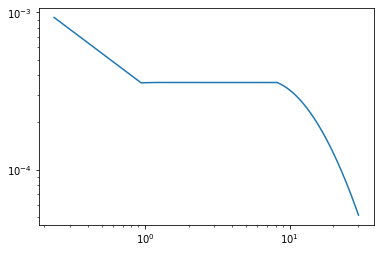

In [33]:
plt.loglog(f, custom_psd_function(f))

In [34]:
def generate_noise_from_psd(psd_func, n_samples, sample_rate): 
    """
    Generate a signal from a given PSD
    
    Parameters:
        psd_func: function
            User's PSD function.
        n_samples: int
            Number of samples to generate.
        sample_rate: float
            sampling rate.
    
    Returns:
        y: ndarray
            Signal generated with the desired PSD.
    """
    # Frequency bins
    freqs = np.fft.rfftfreq(n_samples, d=1/sample_rate)
    valid = freqs > 0.
    freqs = freqs[valid]
    
    #Compute the desired amplitude (sqrt of the PSD)
    psd_target = psd_func(freqs)
    amplitude_spectrum = np.sqrt(psd_target)
    
    #Generate white noise
    random_phases = np.exp(1j * 2 * np.pi * np.random.rand(len(freqs)))
    frequency_domain = amplitude_spectrum * random_phases
    
    #Turn into signal 
    y = np.fft.irfft(frequency_domain, n=n_samples)
    
    #Normalize
    y /= np.std(y)
    
    return(y)
    

In [35]:
x = np.arange(0, 50, 0.016)

y_custom = generate_noise_from_psd(custom_psd_function, len(x), 1/0.016)
y_custom /= SNR
frequencies, psd = welch(y_custom, fs=1/0.016)

fig, ax = plt.subplots(2, 1, figsize=(16,9))
ax[0].plot(x,y_custom, label='Generated signal')
ax[1].loglog(frequencies, psd, label='PSD actual')
plt.show()

NameError: name 'SNR' is not defined

In [ ]:
x = np.arange(-1, 1, 0.016)

y_red = cn.powerlaw_psd_gaussian(2, len(x))
y_red /= SNR
frequencies, psd = welch(y_red, fs=1/0.016)

fig, ax = plt.subplots(2, 1, figsize=(16,9))
ax[0].plot(x,y_red, label='Generated signal')
ax[1].loglog(frequencies, psd, label='PSD actual')
plt.show()

In [ ]:
x = np.arange(-1, 1, 0.016)

y_white = cn.powerlaw_psd_gaussian(0, len(x))
y_white /= SNR
frequencies, psd = welch(y_white, fs=1/0.016)

fig, ax = plt.subplots(2, 1, figsize=(16,9))
ax[0].plot(x,y_white, label='Generated signal')
ax[1].loglog(frequencies, psd, label='PSD actual')
plt.show()

In [ ]:
plt.figure(figsize=(16,8))

frequencies, psd = welch(y_red, fs=1/0.016)
plt.loglog(frequencies, psd, c='r', label='red noise')

frequencies, psd = welch(y_white, fs=1/0.016)
plt.loglog(frequencies, psd, c='grey', label='white noise')

frequencies, psd = welch(y_custom, fs=1/0.016)
plt.loglog(frequencies, psd, c='b', label='custom noise')
plt.legend()
plt.show()